## Weight Initialization Methods in Neural Networks

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.initializers import (
    Zeros, Constant, RandomNormal,
    GlorotUniform, HeNormal
)
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
tf.keras.utils.set_random_seed(42)

X, y = make_moons(n_samples=2000, noise=0.25, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [3]:
def build_model(initializer):
    model = Sequential([
        Dense(64, activation="relu",
              kernel_initializer=initializer, input_shape=(2,)),
        Dense(64, activation="relu",
              kernel_initializer=initializer),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [4]:
initializers = {
    "Zero": lambda: Zeros(),
    "Constant": lambda: Constant(0.1),
    "Random": lambda: RandomNormal(stddev=0.05),
    "Xavier": lambda: GlorotUniform(),
    "He": lambda: HeNormal()
}

results = {}
histories = {}

for name, init_fn in initializers.items():
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)

    model = build_model(init_fn())

    history = model.fit(
        X_train, y_train,
        epochs=40,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    results[name] = {
        "Test Accuracy": accuracy,
        "Test Loss": loss
    }
    histories[name] = history.history

pd.DataFrame(results).T.sort_values(
    "Test Accuracy", ascending=False
)

c:\Users\alili\100_days_Deep_Learning\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Test Accuracy,Test Loss
Random,0.9250,0.173980
Xavier,0.9250,0.174517
He,0.9225,0.178571
Constant,0.8800,0.353982
Zero,0.5000,0.693368


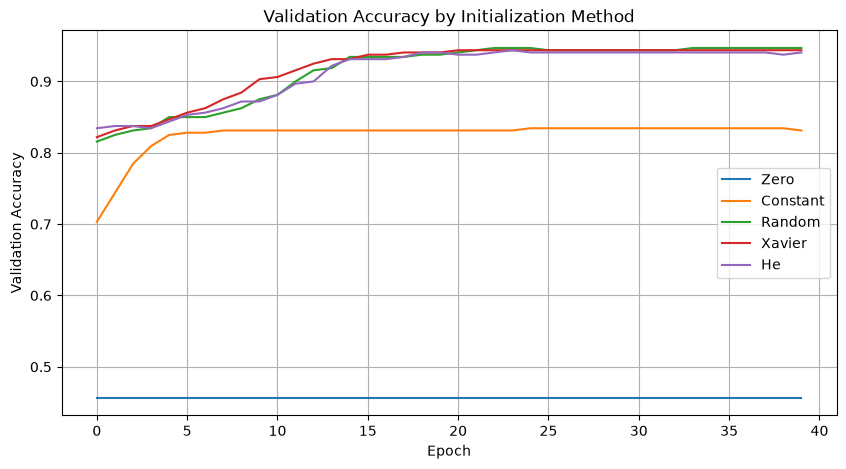

In [8]:
plt.figure(figsize=(10, 5))

for name, history in histories.items():
    plt.plot(history["val_accuracy"], label=name)

plt.title("Validation Accuracy by Initialization Method")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

In [9]:
from tensorflow.keras.layers import LeakyReLU

def build_activation_model(activation, initializer):
    layers = [Dense(64, kernel_initializer=initializer,
                    input_shape=(2,))]

    if activation == "leaky_relu":
        layers.append(LeakyReLU(negative_slope=0.01))
    else:
        layers[-1].activation = tf.keras.activations.get(activation)

    layers.extend([
        Dense(64, kernel_initializer=initializer),
        # Apply the same activation to the second hidden layer
    ])

    if activation == "leaky_relu":
        layers.append(LeakyReLU(negative_slope=0.01))
    else:
        layers[-1].activation = tf.keras.activations.get(activation)

    layers.append(Dense(1, activation="sigmoid"))

    model = Sequential(layers)
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [10]:
activations = ["sigmoid", "tanh", "relu", "leaky_relu"]
init_methods = {
    "Xavier": lambda: GlorotUniform(),
    "He": lambda: HeNormal()
}

comparison = []

for activation in activations:
    for init_name, init_fn in init_methods.items():
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(42)

        model = build_activation_model(activation, init_fn())

        model.fit(
            X_train, y_train,
            epochs=30,
            batch_size=32,
            validation_split=0.2,
            verbose=0
        )

        loss, acc = model.evaluate(X_test, y_test, verbose=0)

        comparison.append({
            "Activation": activation,
            "Initialization": init_name,
            "Test Accuracy": acc,
            "Test Loss": loss
        })

comparison_df = pd.DataFrame(comparison)
comparison_df.sort_values(
    ["Activation", "Test Accuracy"],
    ascending=[True, False]
)

,Activation,Initialization,Test Accuracy,Test Loss
6,leaky_relu,Xavier,0.9250,0.172537
7,leaky_relu,He,0.9225,0.176418
4,relu,Xavier,0.9250,0.172426
5,relu,He,0.9225,0.175599
1,sigmoid,He,0.8950,0.262740
0,sigmoid,Xavier,0.8825,0.299885
2,tanh,Xavier,0.9300,0.168558
3,tanh,He,0.9300,0.174816
